# Análise de datos con PANDAS

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Apertura do CSV

In [11]:

df = pd.DataFrame()
df = pd.read_csv ('datos_covid2021_3paises.csv')
df.head()

,Unnamed: 0,dia,pais,contaxios,mortes
0,0,2021-01-01,Spain,18047,148
1,1,2021-01-02,Spain,0,0
2,2,2021-01-03,Spain,0,0
3,3,2021-01-04,Spain,30579,241
4,4,2021-01-05,Spain,23700,352



### Limpia valores nulos e/ou inválidos/vacíos.

In [13]:
# Verificar valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

# Eliminar filas con valores nulos si es necesario
df = df.dropna()

# Verificar valores indispuestos (0 en contagios y muertes cuando no deberían ser 0)
print("Días con 0 contagios reportados:")
print(df[df['contaxios'] == 0]['dia'].value_counts())

print("Días con 0 informes de muertes:")
print(df[df['mortes'] == 0]['dia'].value_counts())

# Convertir la columna 'dia' a tipo datetime
df['dia'] = pd.to_datetime(df['dia'])

Valores nulos por columna:
Unnamed: 0    0
dia           0
pais          0
contaxios     0
mortes        0
dtype: int64
Días con 0 contagios reportados:
dia
2021-01-16    2
2021-05-22    2
2021-07-31    2
2021-03-19    2
2021-03-21    2
             ..
2021-09-08    1
2021-09-15    1
2021-09-20    1
2021-10-13    1
2021-12-10    1
Name: count, Length: 135, dtype: int64
Días con 0 informes de muertes:
dia
2021-05-22    3
2021-01-16    2
2021-08-22    2
2021-08-21    2
2021-04-10    2
             ..
2021-09-08    1
2021-09-15    1
2021-09-20    1
2021-10-13    1
2021-12-10    1
Name: count, Length: 140, dtype: int64


### 1. Calcula a media de novos casos ao día

In [15]:
# Calcular la media de nuevos casos al día
media_contagios = df['contaxios'].mean()
print(f"Media de nuevos casos al día: {media_contagios:.2f}")

Media de nuevos casos al día: 12094.35


### 2. Calcula a media de mortes ao día

In [17]:
media_muertes = df['mortes'].mean()
print(f"Media de muertes al día: {media_muertes:.2f}")

Media de muertes al día: 98.00


### 3. Calcula o número máximo de casos

In [19]:
max_contagios = df['contaxios'].max()
print(f"Número máximo de los casos en un día: {max_contagios}")

Número máximo de los casos en un día: 232200


### 4. Calcula o número medio de casos separado por grupos

In [21]:
media_por_pais = df.groupby('pais')['contaxios'].mean()
print("Media de casos por país:")
print(media_por_pais)

Media de casos por país:
pais
France      20638.731507
Portugal     2666.789041
Spain       12977.517808
Name: contaxios, dtype: float64


### 5. Existe unha correlación entre número de novos casos e mortes?

Correlación entre nuevos casos y muertes:
           contaxios    mortes
contaxios   1.000000  0.385233
mortes      0.385233  1.000000


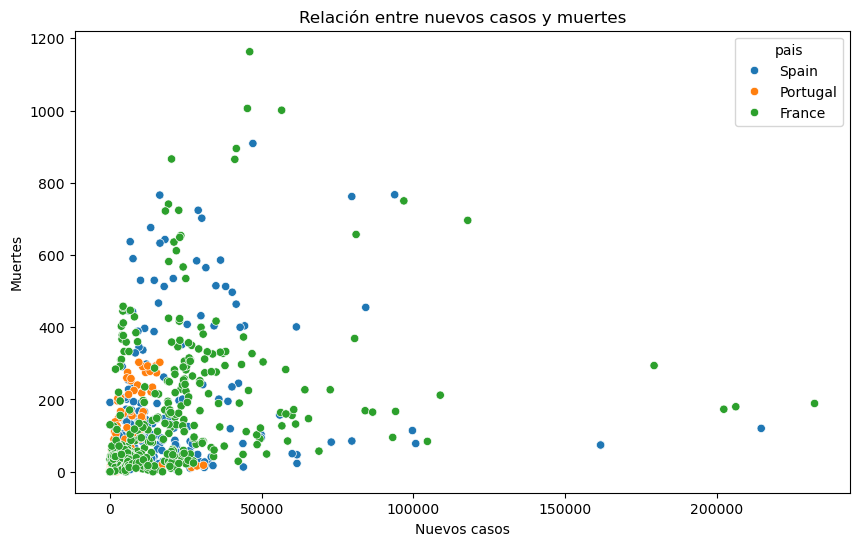

In [23]:
# Calcular la correlación entre 'contaxios' y 'mortes'
correlacion = df[['contaxios', 'mortes']].corr()
print("Correlación entre nuevos casos y muertes:")
print(correlacion)

# Gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='contaxios', y='mortes', hue='pais')
plt.title('Relación entre nuevos casos y muertes')
plt.xlabel('Nuevos casos')
plt.ylabel('Muertes')
plt.show()

### 6. No caso de que exista unha relación, en que país é maior?

In [25]:
# Calcular la correlación por país entre 'contaxios' y 'mortes'
correlacion_por_pais = df.groupby('pais')[['contaxios', 'mortes']].corr().iloc[0::2, 1].reset_index(level=1, drop=True)
print("Correlación por país:")
print(correlacion_por_pais)

# Encontrar el país con la correlación más alta
pais_max_correlacion = correlacion_por_pais.idxmax()
print(f"El país con la correlación más alta es: {pais_max_correlacion}")

Correlación por país:
pais
France      0.298286
Portugal    0.563438
Spain       0.323957
Name: mortes, dtype: float64
El país con la correlación más alta es: Portugal


### 7. Cal é a mediana de casos confirmados en Portugal?

In [27]:
# Filtrar los datos para Portugal
portugal = df[df['pais'] == 'Portugal']

# Calcular la mediana de casos confirmados en Portugal
mediana_portugal = portugal['contaxios'].median()

# Imprimir el resultado
print(f"Mediana de casos confirmados en Portugal: {mediana_portugal}")

Mediana de casos confirmados en Portugal: 1186.0


### 8. Cales son os valores dos percentís Q1 e Q3 de Francia para o número de contaxios

In [29]:
# Filtrar los datos para Francia
francia = df[df['pais'] == 'France']

# Calcular los percentiles Q1 (25%) y Q3 (75%) para el número de contaxios en Francia
q1_francia, q3_francia = francia['contaxios'].quantile([0.25, 0.75])

# Imprimir los resultados
print(f"Q1 (25%) para Francia: {q1_francia}")
print(f"Q3 (75%) para Francia: {q3_francia}")

Q1 (25%) para Francia: 4256.0
Q3 (75%) para Francia: 25087.0


### 9. Cantos valores diferentes hai para o número de contaxios nun día en cada un dos países

In [31]:
# Calcular los valores únicos de contagios por país
valores_unicos = df.groupby('pais')['contaxios'].nunique()

# Imprimir los resultados
print("Valores únicos de contagios por país:")
print(valores_unicos)

Valores únicos de contagios por país:
pais
France      332
Portugal    345
Spain       250
Name: contaxios, dtype: int64


### 10. Valor mínimo e máximo de contaxios por día para cada país

In [33]:
# Calcular el mínimo y máximo de contagios por país
min_max_por_pais = df.groupby('pais')['contaxios'].agg(['min', 'max'])

# Imprimir el resultado
print("Mínimo y máximo de contagios por país:")
print(min_max_por_pais)

Mínimo y máximo de contagios por país:
          min     max
pais                 
France      0  232200
Portugal    0   30829
Spain       0  214619


<h1>Visualizacion adicional:Evolución Temporal<h1>

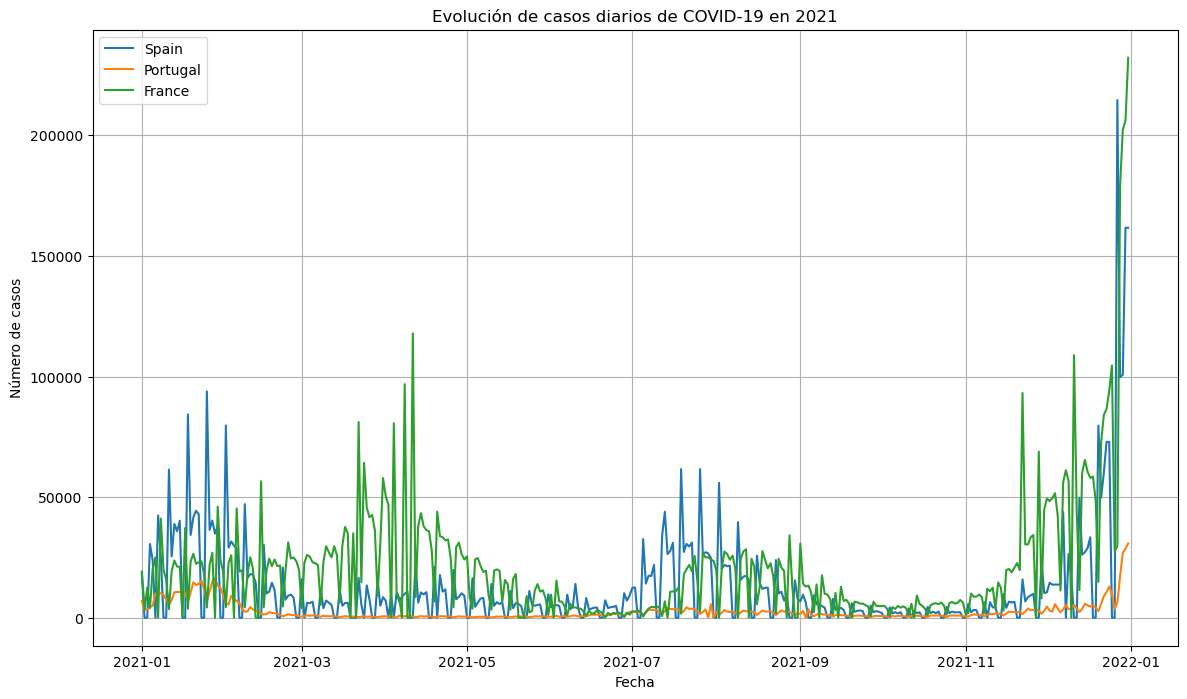

In [35]:
plt.figure(figsize=(14, 8))
for pais in df['pais'].unique():
    datos_pais = df[df['pais'] == pais]
    plt.plot(datos_pais['dia'], datos_pais['contaxios'], label=pais)

plt.title('Evolución de casos diarios de COVID-19 en 2021')
plt.xlabel('Fecha')
plt.ylabel('Número de casos')
plt.legend()
plt.grid()
plt.show()

<h1>Visualización adicional: Muertes por país<h1>

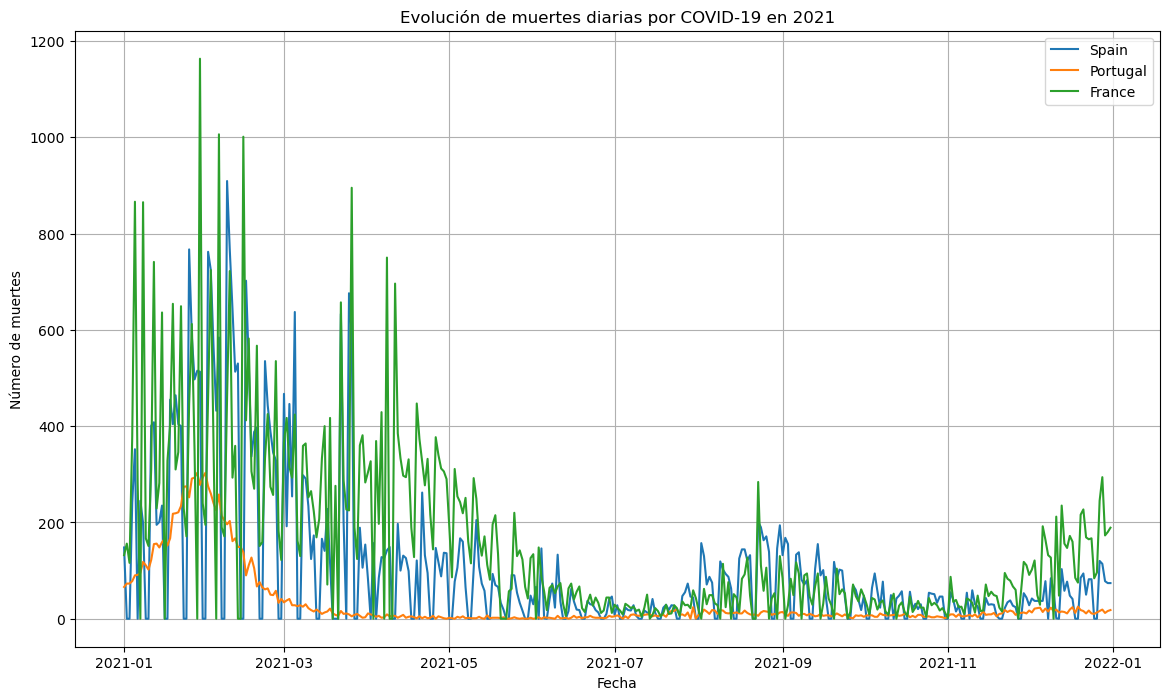

In [37]:
plt.figure(figsize=(14, 8))
for pais in df['pais'].unique():
    datos_pais = df[df['pais'] == pais]
    plt.plot(datos_pais['dia'], datos_pais['mortes'], label=pais)

plt.title('Evolución de muertes diarias por COVID-19 en 2021')
plt.xlabel('Fecha')
plt.ylabel('Número de muertes')
plt.legend()
plt.grid()
plt.show()

<h1>Resumen estadístico por país<h1>

In [39]:
print("En resumen estadístico por país:")
print(df.groupby('pais').describe())

En resumen estadístico por país:
         Unnamed: 0                                                          \
              count   mean    min    25%    50%     75%     max         std   
pais                                                                          
France        365.0  912.0  730.0  821.0  912.0  1003.0  1094.0  105.510663   
Portugal      365.0  547.0  365.0  456.0  547.0   638.0   729.0  105.510663   
Spain         365.0  182.0    0.0   91.0  182.0   273.0   364.0  105.510663   

           dia                       ... contaxios               mortes  \
         count                 mean  ...       max           std  count   
pais                                 ...                                  
France     365  2021-07-02 00:00:00  ...  232200.0  27856.055009  365.0   
Portugal   365  2021-07-02 00:00:00  ...   30829.0   3923.690020  365.0   
Spain      365  2021-07-02 00:00:00  ...  214619.0  22752.942694  365.0   

                                         